In [43]:
import numpy as np
import os
from matplotlib import pyplot as plt
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
from scipy.interpolate import interp1d,PchipInterpolator
import kuibit.simdir as SD
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import glob
from Modules.TOV_Solver_RK45 import TovSolverRK45 as tov
import pickle


In [25]:
freq_code_u_to_hz = 203000
mn = 939.56
n0 = 0.16
epsilon = mn*n0
kg_m3_to_MeV_fm3 = 5.605*10**(-16)
Pa_to_MeV_fm3 = 6.242*10**(-33)

In [31]:
p_central = np.logspace(-2,np.log10(5),100)

In [100]:
def fit_model(k2T,a0,a1,a2,a3,a4):
    return a0*((1.0 + a1*k2T + a2*(k2T**2))/(1.0 + a3*k2T + a4*(k2T**2)))

In [14]:
EOS_V = rvss_eos(1200,mu_max=2700)
EOS_IV = rvss_eos(1300,mu_max=2700)
EOS_III = rvss_eos(1400,mu_max=2700)
EOS_II = rvss_eos(1500,mu_max=2700)
EOS_I = rvss_eos(1700,mu_max=2700)

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [74]:
RVSS_cs2p_interp = {}

EOS_V_cs2p = np.gradient(EOS_V.cs2_unified,EOS_V.chem_pot_unified)
EOS_IV_cs2p = np.gradient(EOS_IV.cs2_unified,EOS_IV.chem_pot_unified)
EOS_III_cs2p = np.gradient(EOS_III.cs2_unified,EOS_III.chem_pot_unified)
EOS_II_cs2p = np.gradient(EOS_II.cs2_unified,EOS_II.chem_pot_unified)
EOS_I_cs2p = np.gradient(EOS_I.cs2_unified,EOS_I.chem_pot_unified)

RVSS_cs2p_interp["V"] = interp1d(EOS_V.P_unified,EOS_V_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["IV"] = interp1d(EOS_IV.P_unified,EOS_IV_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["III"] = interp1d(EOS_III.P_unified,EOS_III_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["II"] = interp1d(EOS_II.P_unified,EOS_II_cs2p,fill_value='extrapolate')
RVSS_cs2p_interp["I"] = interp1d(EOS_I.P_unified,EOS_I_cs2p,fill_value='extrapolate')



In [78]:
solve_I = tov(epsilon,lambda p: EOS_I.eos_interp(p*epsilon)/epsilon,lambda p: EOS_I.nb_interp(p*epsilon),lambda p: EOS_I.cs2_interp(p*epsilon))
solve_II = tov(epsilon,lambda p: EOS_II.eos_interp(p*epsilon)/epsilon,lambda p: EOS_II.nb_interp(p*epsilon),lambda p: EOS_II.cs2_interp(p*epsilon))
solve_III = tov(epsilon,lambda p: EOS_III.eos_interp(p*epsilon)/epsilon,lambda p: EOS_III.nb_interp(p*epsilon),lambda p: EOS_III.cs2_interp(p*epsilon))
solve_IV = tov(epsilon,lambda p: EOS_IV.eos_interp(p*epsilon)/epsilon,lambda p: EOS_IV.nb_interp(p*epsilon),lambda p: EOS_IV.cs2_interp(p*epsilon))
solve_V = tov(epsilon,lambda p: EOS_V.eos_interp(p*epsilon)/epsilon,lambda p: EOS_V.nb_interp(p*epsilon),lambda p: EOS_V.cs2_interp(p*epsilon))

RVSS_Solver_list = {"I":solve_I,
                    "II": solve_II,
                    "III": solve_III,
                    "IV": solve_IV,
                    "V": solve_V}

In [16]:
eos_colors = {"BA": "red",
              "DD2F-SF1": "black",
              "DD2": "orange",
              "BHBlp": "green",
              "SFHo": "purple",
              "BLQ": "gold",
              "SLy4": "turquoise",
              "DD2F": "slategray",
              "BLh": "darkgreen",
              "LS220": "plum",
              }

core_subeos = {
              "DD2": "brown",
              "BHBlp": "green",
              "BLQ": "purple",
              "BLh": "black",
              "LS220": "red"}


In [58]:
p_central = np.logspace(-2,np.log10(5),100)

In [69]:

RVSS_List = {"V" : [EOS_V,'red',0.0039],  
             "IV" : [EOS_IV,'purple',0.0027],
             "III" : [EOS_III,'blue',0.0021],
             "II": [EOS_II,'green',0.0017],
             "I": [EOS_I,'black',0.0012]}   

In [19]:
RVSS_f2_list_1p4 = np.asarray([2.3183139534883717, 2.935739436619718, 0.7318230115361263, 0.7441348973607038])
RVSS_f2_list_1p3 = np.asarray([2.2601524758454103, 2.837993421052632, 3.1352294608472397, 0.71104410331384, 2.5674536256323774])
RVSS_f2_list_1p35 = np.asarray([2.640295504994450315e+00])

RVSS_Mf2_list_1p3 = (2.6)*(RVSS_f2_list_1p3)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p4 = (2.8)*(RVSS_f2_list_1p4)*1000/freq_code_u_to_hz
RVSS_Mf2_list_1p35 = (2.7)*(RVSS_f2_list_1p35)*1000/freq_code_u_to_hz


In [ ]:
core_mvr_data = {}
core_m_cs2_mub_Vavg_interp = {}
core_M_pcentral_interp = {}

for file in os.listdir('./MVR/CORE'):
    file_split = file.split("_")
    eos = file_split[0]
    mvr_data = np.loadtxt(f'./MVR/CORE/{file}',skiprows=1)
    core_mvr_data[eos] = mvr_data
    core_m_cs2_mub_Vavg_interp[eos] = interp1d(mvr_data[:,0],mvr_data[:,6])
    core_M_pcentral_interp[eos] = interp1d(mvr_data[:,0],p_central)


BLh
DD2F
DD2F-SF1
LS220
BHBlp
DD2
SLy4
BA
BLQ
SFHo


In [59]:
rvss_mvr_data = {}
rvss_M_pcentral_interp = {}
rvss_m_cs2_mub_Vavg_interp = {}

for file in os.listdir('./MVR/RVSS'):
    file_split = file.split('_')
    model = file_split[0]
    rvss_mvr_data[model] = np.loadtxt(f'./MVR/RVSS/{file}',skiprows=1)
    rvss_M_pcentral_interp[model] = interp1d(rvss_mvr_data[model][:,0],p_central)
    rvss_m_cs2_mub_Vavg_interp[model] = interp1d(rvss_mvr_data[model][:,0],rvss_mvr_data[model][:,5])

In [22]:
eos_V_M_pr_interp = interp1d(rvss_mvr_data["V"][:,0],p_central)
eos_IV_M_pr_interp = interp1d(rvss_mvr_data["IV"][:,0],p_central)
eos_III_M_pr_interp = interp1d(rvss_mvr_data["III"][:,0],p_central)
eos_II_M_pr_interp = interp1d(rvss_mvr_data["II"][:,0],p_central)
eos_I_M_pr_interp = interp1d(rvss_mvr_data["I"][:,0],p_central)

In [23]:
eos_V_p_1p3 = eos_V_M_pr_interp(1.3)
eos_IV_p_1p3 = eos_IV_M_pr_interp(1.3)
eos_III_p_1p3 = eos_III_M_pr_interp(1.3)
eos_II_p_1p3 = eos_II_M_pr_interp(1.3)
eos_I_p_1p3 = eos_I_M_pr_interp(1.3)

eos_V_p_1p4 = eos_V_M_pr_interp(1.4)
eos_IV_p_1p4 = eos_IV_M_pr_interp(1.4)
eos_III_p_1p4 = eos_III_M_pr_interp(1.4)
eos_II_p_1p4 = eos_II_M_pr_interp(1.4)
eos_I_p_1p4 = eos_I_M_pr_interp(1.4)

eos_IV_p_1p35 = eos_IV_M_pr_interp(1.35)



In [ ]:
def kappa2T(L):
    return (3/16)*L

In [24]:
eos_V_1p3_lambda,eos_V_1p3_k2 = solve_V.solve_tidal(eos_V_p_1p3)
eos_IV_1p3_lambda,eos_IV_1p3_k2 = solve_IV.solve_tidal(eos_IV_p_1p3)
eos_III_1p3_lambda,eos_III_1p3_k2 = solve_III.solve_tidal(eos_III_p_1p3)
eos_II_1p3_lambda,eos_II_1p3_k2 = solve_II.solve_tidal(eos_II_p_1p3)
eos_I_1p3_lambda,eos_I_1p3_k2 = solve_I.solve_tidal(eos_I_p_1p3)

eos_V_1p4_lambda,eos_V_1p4_k2 = solve_V.solve_tidal(eos_V_p_1p4)
eos_IV_1p4_lambda,eos_IV_1p4_k2 = solve_IV.solve_tidal(eos_IV_p_1p4)
eos_III_1p4_lambda,eos_III_1p4_k2 = solve_III.solve_tidal(eos_III_p_1p4)
eos_II_1p4_lambda,eos_II_1p4_k2 = solve_II.solve_tidal(eos_II_p_1p4)
eos_I_1p4_lambda,eos_I_1p4_k2 = solve_I.solve_tidal(eos_I_p_1p4)

eos_IV_1p35_lambda,eos_IV_1p35_k2 = solve_IV.solve_tidal(eos_IV_p_1p35)

eos_I_kappa2T_1p3 = kappa2T(eos_I_1p3_lambda)
eos_II_kappa2T_1p3 = kappa2T(eos_II_1p3_lambda)
eos_III_kappa2T_1p3 = kappa2T(eos_III_1p3_lambda)
eos_IV_kappa2T_1p3 = kappa2T(eos_IV_1p3_lambda)
eos_V_kappa2T_1p3 = kappa2T(eos_V_1p3_lambda)

eos_I_kappa2T_1p4 = kappa2T(eos_I_1p4_lambda)
eos_II_kappa2T_1p4 = kappa2T(eos_II_1p4_lambda)
eos_III_kappa2T_1p4 = kappa2T(eos_III_1p4_lambda)
eos_IV_kappa2T_1p4 = kappa2T(eos_IV_1p4_lambda)
eos_V_kappa2T_1p4 = kappa2T(eos_V_1p4_lambda)

eos_IV_kappa2T_1p35 = kappa2T(eos_IV_1p35_lambda)



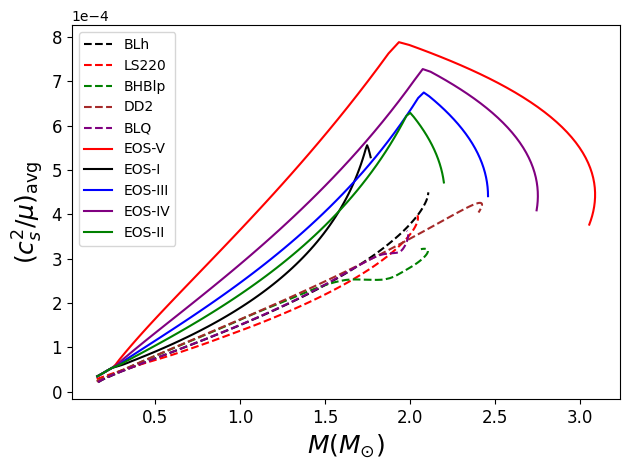

In [17]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2_mub_m_fig,cs2_mub_m_axes = plt.subplots(1)
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        cs2_mub_Vavg = data[:,6]
        mub_cs2p_Vavg = data[:,7]
        cs2_mub_m_axes.plot(M,cs2_mub_Vavg,color=core_subeos[eos],label=eos,linestyle = '--')
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    cs2_mub_Vavg = data_RVSS[:,5]
    mub_cs2p_Vavg = data_RVSS[:,6]
    cs2_mub_m_axes.plot(M,cs2_mub_Vavg,label=f'EOS-{model}',color=RVSS_List[model][0])
cs2_mub_m_axes.legend()
cs2_mub_m_axes.set_xlabel(r'$M(M_{\odot})$',fontsize=axes_label_fontsize)
cs2_mub_m_axes.set_ylabel(r'$(c_s^2/\mu)_{\text{avg}}$',fontsize=axes_label_fontsize)
cs2_mub_m_axes.tick_params(labelsize=tick_label_fontsize)
cs2_mub_m_axes.ticklabel_format(style='sci',axis='y',scilimits=(-4.0,-4.0))
cs2_mub_m_fig.tight_layout()
#cs2_mub_m_fig.savefig('./Figures/Final_Paper_Figs/cs2_mu_avg_M.pdf',format='pdf',dpi=300)




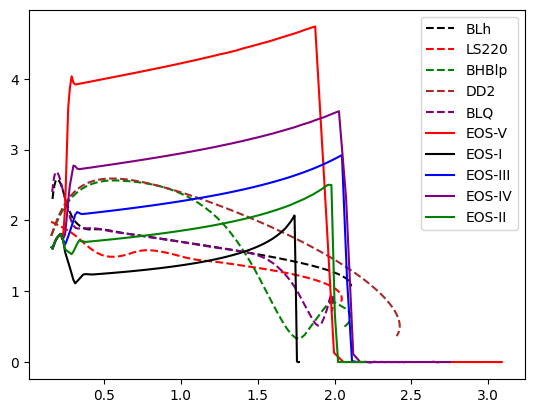

In [18]:
cs2p_mub_fig,csp_mub_axes = plt.subplots()
for eos in core_mvr_data:
    if eos in core_subeos:
        data = core_mvr_data[eos]
        M = data[:,0]
        R = data[:,1]
        mub_cs2p_Vavg = data[:,7]
        csp_mub_axes.plot(M,mub_cs2p_Vavg,color=core_subeos[eos],linestyle = '--',label=eos)
for model in rvss_mvr_data:
    data_RVSS = rvss_mvr_data[model]
    M = data_RVSS[:,0]
    R = data_RVSS[:,1]
    mub_cs2p_Vavg = data_RVSS[:,6]
    csp_mub_axes.plot(M,mub_cs2p_Vavg,color=RVSS_List[model][0],label=f"EOS-{model}")
csp_mub_axes.legend()



In [89]:
core_db_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB'
core_db_eos_path = '/home/john/UW_PhD_Program/RVSS_Slope_Parametrization/coreDB/THC_DB/THC/DB/EOS'
sim_names = [name for name in os.listdir(core_db_path) if os.path.isdir(os.path.join(core_db_path,name)) and (name != 'EOS' and name != 'SkyNet')]
eos_list = [name for name in os.listdir(core_db_eos_path) if os.path.isdir(os.path.join(core_db_eos_path,name))]
sim_dirs = {}

sim_info = {}

for sim in sim_names:
    sim_info[sim] = {}
    sim_name_parsed = sim.split('_')
    eos_name = sim_name_parsed[0]
    mass_1 = float(sim_name_parsed[1])
    mass_2 = float(sim_name_parsed[2])
    mass_total = mass_1 + mass_2

    sim_info[sim]['m1'] = mass_1
    sim_info[sim]['m2'] = mass_2

    sim_info[sim]['m_total'] = mass_total
    sim_info[sim]['eos'] = eos_name

    metadata = os.path.abspath(os.path.join(core_db_path,sim,'metadata.txt'))
    with open(metadata,'r') as file:
        lines = file.readlines()
        for line in lines:
            line = line.strip('\n')
            line_split = line.split(' ')
            line_split = [x for x in line_split if x]
            if len(line_split) > 0:
                if line_split[0] == 'id_kappa2T':
                    sim_info[sim]["kappa_2T"] = float(line_split[-1])
                if line_split[0] == 'id_Lambda':
                    sim_info[sim]["Lambda_2T"] = float(line_split[-1])
                if line_split[0] == 'id_spin_starA':
                    sim_info[sim]["spin1"] = [float(line_split[-3].strip(',')),float(line_split[-2].strip(',')),float(line_split[-1].strip(','))]
                    
    

In [36]:
eos_cs2 = {}
eos_eden = {}
eos_press = {}
eos_dens = {}
eos_mub = {}

eos_alpha = {}
eos_beta = {}
eos_interp = {}
dens_interp = {}
alpha_interp = {}
beta_interp = {}
eos_mub_interp = {}

eos_cs2_interp = {}

for eos_name in eos_list:
    if os.path.isdir(os.path.join(core_db_eos_path,eos_name)):
        pizza_files = glob.glob(os.path.join(core_db_eos_path,eos_name,'*.pizza'))
        with open(pizza_files[0]) as eos_file:
            eos_data = np.loadtxt(eos_file,skiprows=5)
            if(eos_data.shape[0] == 3): continue
            else:
                eos_dens[eos_name] = eos_data[:,0] * kg_m3_to_MeV_fm3 * (1/mn)
                eos_cs2[eos_name] = eos_data[:,3]
                eos_eden[eos_name] = (eos_data[:,1] + 1) * mn * eos_dens[eos_name]
                eos_press[eos_name] = eos_data[:,2] * Pa_to_MeV_fm3
                eos_mub[eos_name] = (eos_eden[eos_name] + eos_press[eos_name])/(eos_dens[eos_name])
    eos_cs2_interp[eos_name] = interp1d(eos_press[eos_name],eos_cs2[eos_name],fill_value='extrapolate')
    eos_beta[eos_name] = np.gradient(eos_cs2[eos_name],eos_dens[eos_name])
    eos_alpha[eos_name] = np.gradient(eos_cs2[eos_name],eos_mub[eos_name])
    eos_interp[eos_name] = PchipInterpolator(eos_press[eos_name],eos_eden[eos_name])
    dens_interp[eos_name] = PchipInterpolator(eos_press[eos_name],eos_dens[eos_name])
    alpha_interp[eos_name] = interp1d(eos_press[eos_name],eos_alpha[eos_name],fill_value='extrapolate')
    beta_interp[eos_name] = interp1d(eos_press[eos_name],eos_beta[eos_name],fill_value='extrapolate')
    eos_mub_interp[eos_name] = interp1d(eos_press[eos_name],eos_mub[eos_name],fill_value='extrapolate')

def create_solver(eos_i, epsilon):
    return tov(
        epsilon,
        eos = lambda p: eos_interp[eos_i](p * epsilon) / epsilon,
        bary_density= lambda p: dens_interp[eos_i](p * epsilon),
        dpde=lambda p: eos_cs2_interp[eos_i](p* epsilon)
    )

solver_list = {eos_i : create_solver(eos_i, epsilon) for eos_i in eos_interp.keys()}

In [96]:
kb_sim_dirs = {}

for eos in sim_names:
    kb_sim_dirs[eos] = SD.SimDir(os.path.abspath(os.path.join(core_db_path,eos)))
p_cut = 600

core_db_strain = {}
core_db_gws = {}
core_db_gw_phase = {}
core_db_gw_inst_freq = {}
core_db_gw_asd = {}
core_db_gw_htilde = {}

core_fpeak = {}

for sim_name in kb_sim_dirs:
    sd = kb_sim_dirs[sim_name]
    core_db_strain[sim_name] = {}
    core_db_gws[sim_name] = {}
    for gw in sd.gws:
        extr_radius = str(gw.radius)
        core_db_gws[sim_name][extr_radius] = gw
        strain = gw.get_strain_lm(2,
                                2,
                                p_cut,
                                0.1,
                                window_function='tukey')
        core_db_strain[sim_name][extr_radius] = strain

for sim in core_db_strain:
    core_db_gw_phase[sim] = {}
    core_db_gw_inst_freq[sim] = {}
    for r in core_db_strain[sim]:
        time = core_db_strain[sim][r].t
        real_h = np.real(core_db_strain[sim][r].y)
        imag_h = np.imag(core_db_strain[sim][r].y)
        phase = np.unwrap(np.arctan2(real_h,imag_h))
        
        core_db_gw_phase[sim][r] = phase
        core_db_gw_inst_freq[sim][r] = (1/(2*np.pi))*np.gradient(phase,time)
    
    core_db_gw_asd[sim] = {}
    core_db_gw_htilde[sim] = {}
    for r in core_db_strain[sim]:
        h_plus = core_db_strain[sim][r].real()
        h_cross = core_db_strain[sim][r].imag()

        h_plus_tilde = h_plus.to_FrequencySeries()
        h_cross_tilde = h_cross.to_FrequencySeries()

        h_tilde = np.sqrt((h_plus_tilde.real()**2 + h_plus_tilde.imag()**2) + (h_cross_tilde.real()**2 + h_cross_tilde.imag()**2))
        core_db_gw_htilde[sim][r] = h_tilde
        core_db_gw_asd[sim][r] = 2.0*h_tilde.fft*np.sqrt(h_tilde.f*freq_code_u_to_hz)
    core_fpeak[sim] = core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])]*freq_code_u_to_hz/1000

    sim_info[sim]['Mfpeak'] = (core_db_gw_htilde[sim]['400.0'].f[np.argmax(core_db_gw_asd[sim]['400.0'])])*(sim_info[sim]['m_total'])
    sim_info[sim]['fpeak'] = core_fpeak[sim]


<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0

/home/john/.local/lib/python3.10/site-packages/kuibit/timeseries.py:769: RuntimeWarning: TimeSeries is not regularly samples. Resampling.
  warnings.warn(


<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0x7de6bb53b250>
<function tukey at 0

In [46]:
core_cs2p_interp = {}
for file in os.listdir('./Core_EOS_Interpreters'):
    file_split = file.split('_')
    eos = file_split[0]
    with open (f'./Core_EOS_Interpreters/{file}','rb') as pkl_file:
        core_cs2p_interp[eos] = pickle.load(pkl_file)
        print(eos)

SLy
SLy4
BLQ
BHBlp
LS220
MS1b
BA
DD2F-SF1
BLh
DD2
SFHo
DD2F


In [94]:
sim_info_core_subeos = {}
for sim in sim_info:
    if sim_info[sim]['eos'] in core_subeos and sim_info[sim]['m1'] == sim_info[sim]['m2'] and sim_info[sim]['spin1'] == [0.0,0.0,0.0]:
        sim_info_core_subeos[sim] = sim_info[sim]
        sim_info_core_subeos[sim]['cs2mub_Vavg'] = float(core_m_cs2_mub_Vavg_interp[sim_info[sim]['eos']](sim_info[sim]['m1']))
        p_central = core_M_pcentral_interp[sim_info[sim]['eos']](sim_info[sim]['m1'])
        solution,nu = solver_list[sim_info[sim]['eos']].solve_nu(p_central)
        n_r = dens_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        n_c = dens_interp[sim_info[sim]['eos']](solution.y[0,0]*epsilon)

        cs2p_r = core_cs2p_interp[sim_info[sim]['eos']](solution.y[0,:]*epsilon)
        cs2p_r_interp = interp1d(solution.t,cs2p_r,fill_value='extrapolate')
        NS_nb_r_interp = interp1d(n_r,solution.t,fill_value='extrapolate')
        r_stop = NS_nb_r_interp((2.0/3.0)*n_c)

        
        cs2p_Vavg = solver_list[sim_info[sim]['eos']].ns_vol_avg(cs2p_r_interp,r_stop,solution=solution,nu_sol=nu)
        sim_info_core_subeos[sim]['cs2p_Vavg'] = cs2p_Vavg
        print(cs2p_Vavg)
        


0.001576331175052843
0.0014660251612484338
0.0014721871840992836
0.0016118834423536818


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/Modules/TOV_Solver_RK45.py:137: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Vol_avg_integral = quad(vol_avg_integrand,a=1e-3,b=r_stop)[0]


0.002078370890648657
0.0014264781244512441
0.0014721871840992836
0.0014251195580393908
0.0013989065531623045


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/Modules/TOV_Solver_RK45.py:137: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Vol_avg_integral = quad(vol_avg_integrand,a=1e-3,b=r_stop)[0]


0.0014057696078533452
0.0016198915858538197
0.0014797683102179054
0.001459820869210948
0.0014431780249789796
0.0018315838309313414
0.0014721871840992836
0.0014554725677326883
0.0014972483937038266
0.0016457229829748463
0.0016259611438345352
0.0016015583920041343
0.001787582735699341
0.0014568977434289475
0.001410676544448225
0.0014721871840992836
0.0014251195580393908
0.0016677965284210318
0.001459820869210948
0.0016259611438345352
0.0014264781244512441
0.0013992834356132706
0.001646893848227439
0.0014182938767464098
0.0016198915858538197
0.0014797683102179054
0.0016017118970302893
0.0014129564492438226
0.0013992834356132706
0.0014020471618044193
0.001459820869210948
0.0014264781244512441
0.0014721871840992836
0.0022796154760261473
0.0014721871840992836
0.001426260004042032
0.0016198915858538197
0.001459820869210948
0.001433991696476961
0.001410676544448225
0.0015885129073726562
0.0015029935977444566
0.0014660251612484338
0.001433991696476961
0.0014260340772836533
0.0014554725677326883

In [76]:
sim_info_RVSS = {'EOS_I_1p3':{'m':1.3,'lambda':eos_I_1p3_lambda,'kappa_2T':eos_I_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[3],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["I"](1.3),'model':"I"},
                 'EOS_I_1p4':{'m':1.4,'lambda':eos_I_1p4_lambda,'kappa_2T':eos_I_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[3],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["I"](1.4),'model':"I"},
                 'EOS_II_1p3':{'m':1.3,'lambda':eos_II_1p3_lambda,'kappa_2T':eos_II_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[2],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["II"](1.3),'model':"II"},
                 'EOS_II_1p4':{'m':1.4,'lambda':eos_II_1p4_lambda,'kappa_2T':eos_II_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[2],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["II"](1.4),'model':"II"},
                 'EOS_III_1p3':{'m':1.3,'lambda':eos_III_1p3_lambda,'kappa_2T':eos_III_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[1],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["III"](1.3),'model':"III"},
                 'EOS_III_1p4':{'m':1.4,'lambda':eos_III_1p4_lambda,'kappa_2T':eos_III_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[1],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["III"](1.4),'model':"III"},
                 'EOS_IV_1p3':{'m':1.3,'lambda':eos_IV_1p3_lambda,'kappa_2T':eos_IV_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[4],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["IV"](1.3),'model':"IV"},
                 'EOS_IV_1p35':{'m':1.35,'lambda':eos_IV_1p35_lambda,'kappa_2T':eos_IV_kappa2T_1p35,'Mfpeak':RVSS_Mf2_list_1p35[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["IV"](1.35),'model':"IV"},
                 'EOS_V_1p3':{'m':1.3,'lambda':eos_V_1p3_lambda,'kappa_2T':eos_V_kappa2T_1p3,'Mfpeak':RVSS_Mf2_list_1p3[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["V"](1.3),'model':"V"},
                 'EOS_V_1p4':{'m':1.4,'lambda':eos_V_1p4_lambda,'kappa_2T':eos_V_kappa2T_1p4,'Mfpeak':RVSS_Mf2_list_1p4[0],'cs2_mub_vavg':rvss_m_cs2_mub_Vavg_interp["V"](1.4),'model': "V"}}

In [79]:
for sim in sim_info_RVSS:
    sim_model = sim_info_RVSS[sim]['model']
    m = sim_info_RVSS[sim]['m']
    p_c = rvss_M_pcentral_interp[sim_model](m)
    solution,nu = RVSS_Solver_list[model].solve_nu(p_c)

    nb_r = RVSS_List[sim_model][0].nb_interp(solution.y[0,:])
    r_nb_interp = interp1d(nb_r,solution.t)
    r_stop = r_nb_interp((2.0/3.0)*RVSS_List[sim_model][0].nb_interp(solution.y[0,0]))

    cs2p_r_interp = interp1d(solution.t,RVSS_cs2p_interp[sim_model](solution.y[0,:]),fill_value='extrapolate')

    sim_info_RVSS[sim]['cs2p_Vavg'] = RVSS_Solver_list[sim_model].ns_vol_avg(cs2p_r_interp,r_stop,solution=solution,nu_sol=nu)
    print(sim_model)    

/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/Modules/TOV_Solver_RK45.py:137: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Vol_avg_integral = quad(vol_avg_integrand,a=1e-3,b=r_stop)[0]


I
I
II


/home/john/UW_PhD_Program/Projects/2026/HD_Cs2_Plotting_Scripts/Modules/TOV_Solver_RK45.py:137: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Vol_avg_integral = quad(vol_avg_integrand,a=1e-3,b=r_stop)[0]


II
III
III
IV
IV
V
V


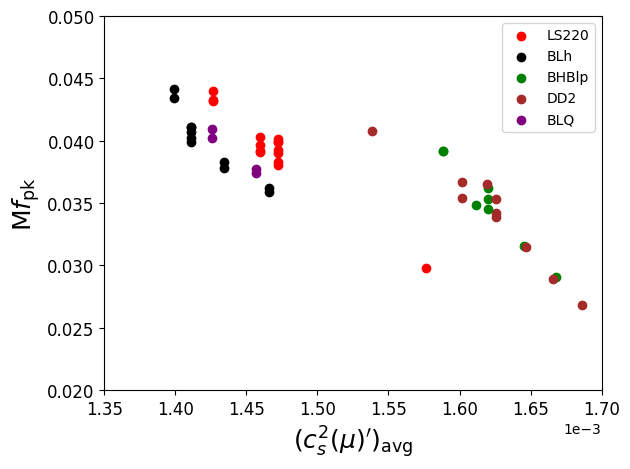

In [138]:
eos_labeled = {}
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16
cs2p_mf2_fig,cs2p_mf2_axes = plt.subplots(1)
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['eos'] not in eos_labeled:
        eos_labeled[sim_info_core_subeos[sim]['eos']] = False
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02 and not eos_labeled[sim_info_core_subeos[sim]['eos']]:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']],label=sim_info_core_subeos[sim]['eos'])
        eos_labeled[sim_info_core_subeos[sim]['eos']] = True
    else:
        cs2p_mf2_axes.scatter(sim_info_core_subeos[sim]['cs2p_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color=core_subeos[sim_info_core_subeos[sim]['eos']])

cs2p_mf2_axes.set_ylim([0.02,0.05])
cs2p_mf2_axes.set_xlim([0.00135,0.0017])

cs2p_mf2_axes.set_ylabel(r"$\text{M}f_{\text{pk}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}$",fontsize=axes_label_fontsize)
cs2p_mf2_axes.tick_params(labelsize=tick_label_fontsize)
cs2p_mf2_axes.legend()
cs2p_mf2_axes.ticklabel_format(style='sci',axis='x',scilimits=(-3,-3))
cs2p_mf2_fig.tight_layout()
cs2p_mf2_fig.savefig('./Figures/Final_Paper_Figs/Mfpk_cs2p_core.pdf',format='pdf',dpi=300)






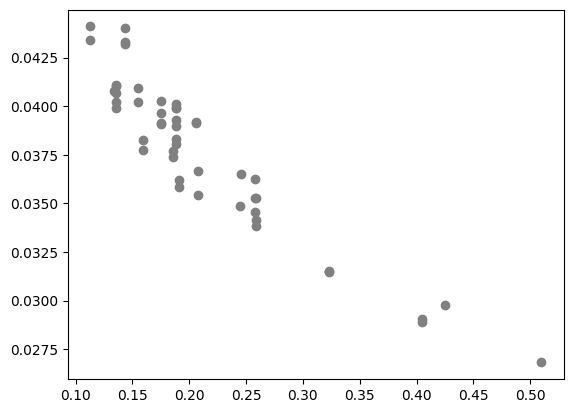

In [101]:
simulations_for_fit = {}
for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.02:
        plt.scatter(sim_info_core_subeos[sim]['cs2p_Vavg']*sim_info[sim]['kappa_2T'],sim_info[sim]['Mfpeak'],color='gray')
        simulations_for_fit[sim] = sim_info_core_subeos[sim]

In [110]:
k2T_cs2_mub_list = np.linspace(0,0.06,200)
k2T_list = np.linspace(50,400,200)
k2T_cs2p_list = np.linspace(0.10,0.50,200)

In [112]:
mfpk_fit = np.asarray([sim_info[sim]['Mfpeak'] for sim in simulations_for_fit])
k2T_cs2p_vavg_fit= np.asarray([sim_info[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2p_Vavg'] for sim in simulations_for_fit])

In [113]:
popt_k2t_cs2p,pcov_k2t_cs2p = curve_fit(fit_model,k2T_cs2p_vavg_fit,mfpk_fit,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p = popt_k2t_cs2p
mf2_pred = fit_model(k2T_cs2p_vavg_fit,a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p)
r2_k2t_cs2p = r2_score(mfpk_fit,mf2_pred)
print(r2_k2t_cs2p)


0.9016956225352958


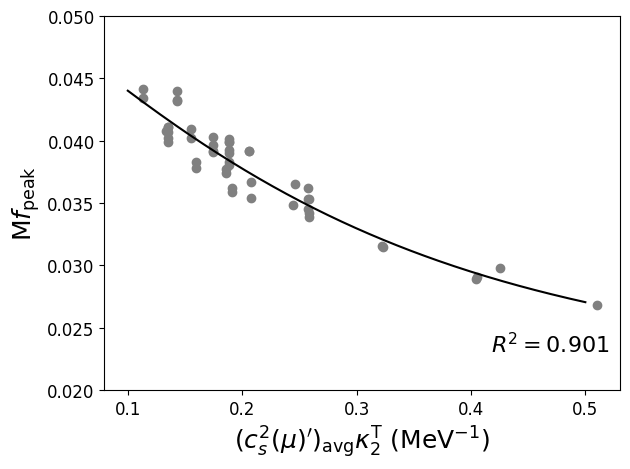

In [118]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16

kappa2T_cs2p_fig,kappa2T_cs2p_axes = plt.subplots(1)
kappa2T_cs2p_axes.plot(k2T_cs2p_list,fit_model(k2T_cs2p_list,a0_cs2p,a1_cs2p,a2_cs2p,a3_cs2p,a4_cs2p),color='black')
kappa2T_cs2p_axes.scatter(k2T_cs2p_vavg_fit,mfpk_fit,color='grey')
kappa2T_cs2p_axes.set_xlabel(r"$(c_s^2(\mu)')_{\text{avg}}\kappa_2^{\text{T}} \text{ (MeV}^{-1})$",fontsize=axes_label_fontsize)
kappa2T_cs2p_axes.set_ylabel(r'$\text{M}f_{\text{peak}}$',fontsize=axes_label_fontsize)
#kappa2T_cs2p_axes.set_xlim([0.01,0.06])
kappa2T_cs2p_axes.set_ylim([0.02,0.05])
kappa2T_cs2p_axes.text(0.75,0.1,r"$R^2 = 0.901$",transform=kappa2T_cs2p_axes.transAxes,fontsize=text_fontsize)
kappa2T_cs2p_axes.tick_params(labelsize=tick_label_fontsize)
kappa2T_cs2p_fig.tight_layout()

kappa2T_cs2p_fig.savefig("./Figures/Final_Paper_Figs/Mfpk_k2Tcs2p_vavg.pdf",format='pdf',dpi=300)

Text(0, 0.5, '$\\text{M}f_{\\text{peak}}$')

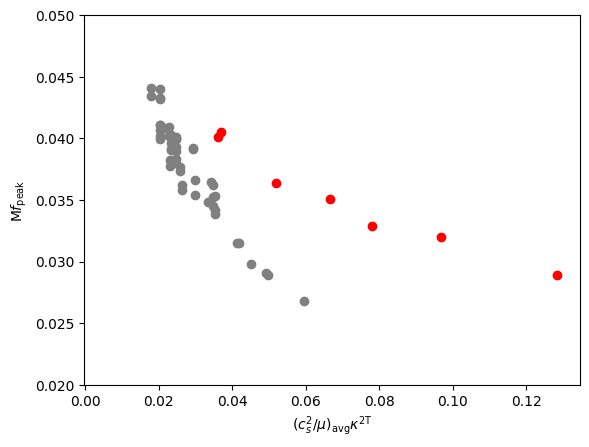

In [24]:
for sim in sim_info_core_subeos:
    plt.scatter(sim_info_core_subeos[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2mub_Vavg'],sim_info_core_subeos[sim]['Mfpeak'],color='gray')
for sim in sim_info_RVSS:
    plt.scatter(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'],sim_info_RVSS[sim]['Mfpeak'],color='red')

plt.gca().set_ylim([0.020,0.050])
#plt.gca().set_xlim([50,350])

plt.gca().set_xlabel(r'$(c_s^2/\mu)_{\text{avg}}\kappa^{\text{2T}}$')
plt.gca().set_ylabel(r'$\text{M}f_{\text{peak}}$')


Text(0, 0.5, '$\\text{M}f_{\\text{peak}}$')

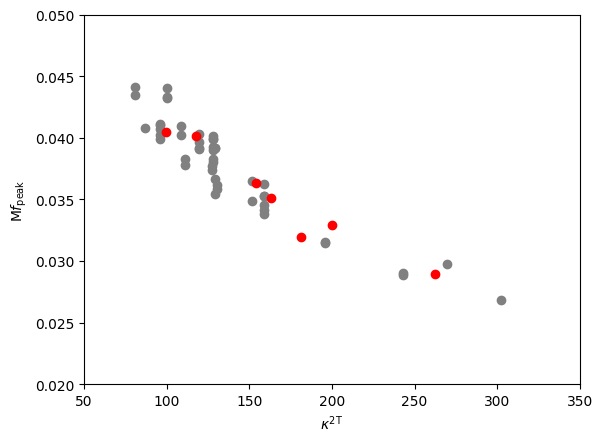

In [25]:
for sim in sim_info_core_subeos:
    plt.scatter(sim_info_core_subeos[sim]['kappa_2T'],sim_info_core_subeos[sim]['Mfpeak'],color='gray')
for sim in sim_info_RVSS:
    plt.scatter(sim_info_RVSS[sim]['kappa_2T'],sim_info_RVSS[sim]['Mfpeak'],color='red')

plt.gca().set_ylim([0.020,0.050])
plt.gca().set_xlim([50,350])

plt.gca().set_xlabel(r'$\kappa^{\text{2T}}$')
plt.gca().set_ylabel(r'$\text{M}f_{\text{peak}}$')

In [129]:
k2T = []
k2T_cs2mub = []
Mf2 = []

k2T_Rvss = []
k2T_cs2mub_rvss = []
Mf2_rvss = []

for sim in sim_info_RVSS:
    
    # k2T.append(sim_info_RVSS[sim]['kappa_2T'])
    # Mf2.append(sim_info_RVSS[sim]['Mfpeak'])
    # k2T_cs2mub.append(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'])
    k2T_Rvss.append(sim_info_RVSS[sim]['kappa_2T'])
    Mf2_rvss.append(sim_info_RVSS[sim]["Mfpeak"])
    k2T_cs2mub_rvss.append(sim_info_RVSS[sim]['kappa_2T']*sim_info_RVSS[sim]['cs2_mub_vavg'])

for sim in sim_info_core_subeos:
    if sim_info_core_subeos[sim]['Mfpeak'] > 0.020:
        k2T.append(sim_info_core_subeos[sim]['kappa_2T'])
        Mf2.append(sim_info_core_subeos[sim]["Mfpeak"])
        k2T_cs2mub.append(sim_info_core_subeos[sim]['kappa_2T']*sim_info_core_subeos[sim]['cs2mub_Vavg'])

        


k2T = np.asarray(k2T)
k2T_cs2mub = np.asanyarray(k2T_cs2mub)
Mf2 = np.asanyarray(Mf2)

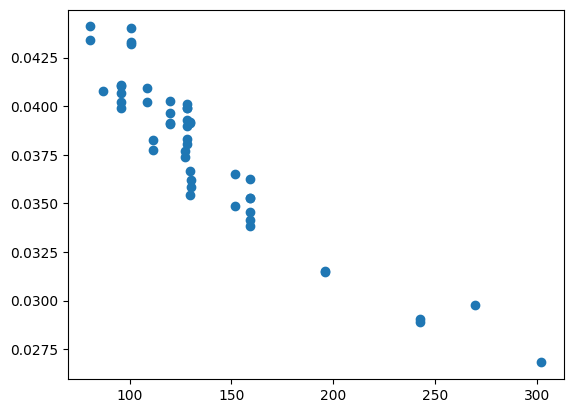

In [93]:
plt.scatter(k2T,Mf2)

In [45]:
popt_k2t,pcov_k2t = curve_fit(fit_model,k2T,Mf2,(1.0,1.0,1.0,1.0,1.0),maxfev=5000,bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0,a1,a2,a3,a4 = popt_k2t
mf2_pred = fit_model(k2T,a0,a1,a2,a3,a4)
print(popt_k2t)
r2_k2t = r2_score(Mf2,mf2_pred)
print(r2_k2t)

[1.65422186e-06 7.91659278e+02 3.14920691e+00 2.27130569e-11
 3.44049097e-04]
0.896623552286897


In [36]:
k2t_cs2_scaled = k2T_cs2mub*5000
popt_k2Tcs2mub,pcov_k2tcs2mub = curve_fit(fit_model,k2t_cs2_scaled,Mf2,(popt_k2t[0],popt_k2t[1],popt_k2t[2],0.1,popt_k2t[4]),maxfev=5000,method='dogbox',bounds=([0,0,0,0,0],[np.inf,np.inf,np.inf,np.inf,np.inf]))
a0_cs,a1_cs,a2_cs,a3_cs,a4_cs = popt_k2Tcs2mub
print(popt_k2Tcs2mub)
mf2_pred = fit_model(k2t_cs2_scaled,a0_cs,a1_cs,a2_cs,a3_cs,a4_cs)
r2_k2tcs2mub = r2_score(Mf2,mf2_pred)
print(r2_k2tcs2mub)

[1.27700965e+02 4.09023313e-02 1.54564215e-05 1.25574632e+02
 3.37694263e-01]
0.9112085267050676


In [127]:
a0 = 1.65422186e-06
a1 = 7.91659278e+02
a2 = 3.14920691e+00
a3 = 2.27130569e-11
a4 = 3.44049097e-04

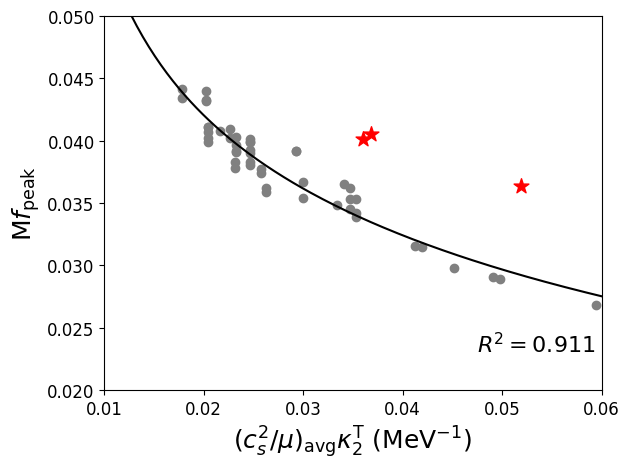

In [41]:
axes_label_fontsize = 18
tick_label_fontsize = 12
text_fontsize = 16

kappa2T_cs2_mub_fig,kappa2T_cs2_axes = plt.subplots(1)
kappa2T_cs2_axes.plot(k2T_cs2_mub_list,fit_model(k2T_cs2_mub_list*5000,a0_cs,a1_cs,a2_cs,a3_cs,a4_cs),color='black')
kappa2T_cs2_axes.scatter(k2T_cs2mub,Mf2,color='gray')
kappa2T_cs2_axes.scatter(k2T_cs2mub_rvss,Mf2_rvss,marker='*',s=125,color='red')
kappa2T_cs2_axes.set_xlabel(r'$(c_s^2/\mu)_{\text{avg}}\kappa_2^{\text{T}} \text{ (MeV}^{-1})$',fontsize=axes_label_fontsize)
kappa2T_cs2_axes.set_ylabel(r'$\text{M}f_{\text{peak}}$',fontsize=axes_label_fontsize)
kappa2T_cs2_axes.set_xlim([0.01,0.06])
kappa2T_cs2_axes.set_ylim([0.02,0.05])
kappa2T_cs2_axes.text(0.75,0.1,r"$R^2 = 0.911$",transform=kappa2T_cs2_axes.transAxes,fontsize=text_fontsize)
kappa2T_cs2_axes.tick_params(labelsize=tick_label_fontsize)
kappa2T_cs2_mub_fig.tight_layout()

kappa2T_cs2_mub_fig.savefig("./Figures/Final_Paper_Figs/Mfpk_k2Tcs2mub.pdf",format='pdf',dpi=300)


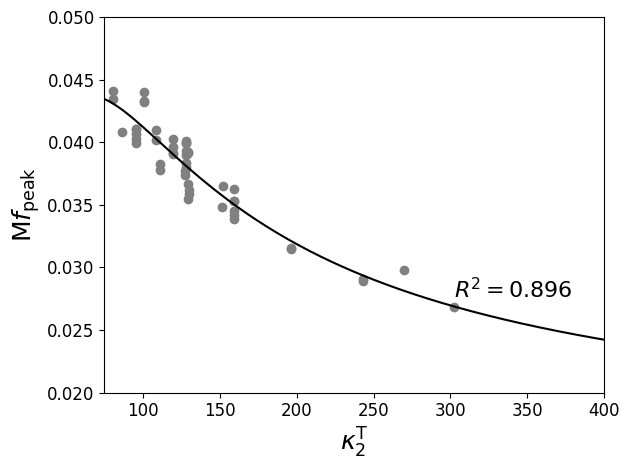

In [132]:
k2T_mf2_fig,k2T_mf2_axes = plt.subplots(1)

k2T_mf2_axes.scatter(k2T,Mf2,color='gray')
#k2T_mf2_axes.scatter(k2T_Rvss,Mf2_rvss,marker='*',s=125,color='red')
k2T_mf2_axes.plot(k2T_list,fit_model(k2T_list,a0,a1,a2,a3,a4),color='black')

k2T_mf2_axes.set_xlabel(r'$\kappa_2^{\text{T}}$',fontsize=axes_label_fontsize)
k2T_mf2_axes.set_ylabel(r'$\text{M}f_{\text{peak}}$',fontsize=axes_label_fontsize)
k2T_mf2_axes.set_xlim([75,400])
k2T_mf2_axes.set_ylim([0.02,0.05])
k2T_mf2_axes.text(0.70,0.25,r"$R^2 = 0.896$",transform=k2T_mf2_axes.transAxes,fontsize=text_fontsize)
k2T_mf2_axes.tick_params(labelsize=tick_label_fontsize)
k2T_mf2_fig.tight_layout()
k2T_mf2_fig.savefig('./Figures/Final_Paper_Figs/mfpk_k2t.pdf',format='pdf',dpi=300)

